In [1]:
import numpy as np
import healpy as hp
from astropy.io import fits
from astropy.table import Table
from astropy import units as u
from astropy.coordinates import SkyCoord
import pandas as pd

import astropy.coordinates as ac
from mpl_toolkits.basemap import Basemap

from gala.coordinates import MagellanicStreamNidever08
import matplotlib.pyplot as plt
import os
%matplotlib inline

# Load data and paths

In [2]:
# set up the plotting
# set font size
plt.rcParams.update({'font.size': 18})
# set the figure size
plt.rcParams.update({'figure.figsize': (10, 7)})
# set the font to latex
plt.rcParams.update({'text.usetex': True})

In [3]:
plot_path = '/Users/mncavieres/Documents/2024-1/Delve/Proposal/Plots/V2'

In [4]:
giants = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Proposal/Catalog/giants_polygon_distances_streamcoordsxGaia.fits')
giants

a_image_g,a_image_i,a_image_r,a_image_z,b_image_g,b_image_i,b_image_r,b_image_z,ccdnum_g,ccdnum_i,ccdnum_r,ccdnum_z,class_star_g,class_star_i,class_star_r,class_star_z,dec,ebv,expnum_g,expnum_i,expnum_r,expnum_z,exptime_g,exptime_i,exptime_r,exptime_z,extended_class_g,extended_class_i,extended_class_r,extended_class_z,extinction_g,extinction_i,extinction_r,extinction_z,flags_g,flags_i,flags_r,flags_z,hpx2048,htm9,mag_auto_g,mag_auto_i,mag_auto_r,mag_auto_z,mag_psf_g,mag_psf_i,mag_psf_r,mag_psf_z,magerr_auto_g,magerr_auto_i,magerr_auto_r,magerr_auto_z,magerr_psf_g,magerr_psf_i,magerr_psf_r,magerr_psf_z,nepochs_g,nepochs_i,nepochs_r,nepochs_z,nest4096,quick_object_id,ra,random_id,ring256,spread_model_g,spread_model_i,spread_model_r,spread_model_z,spreaderr_model_g,spreaderr_model_i,spreaderr_model_r,spreaderr_model_z,t_eff_g,t_eff_i,t_eff_r,t_eff_z,theta_image_g,theta_image_i,theta_image_r,theta_image_z,wavg_flags_g,wavg_flags_i,wavg_flags_r,wavg_flags_z,wavg_mag_auto_g,wavg_mag_auto_i,wavg_mag_auto_r,wavg_mag_auto_z,wavg_mag_psf_g,wavg_mag_psf_i,wavg_mag_psf_r,wavg_mag_psf_z,wavg_magerr_auto_g,wavg_magerr_auto_i,wavg_magerr_auto_r,wavg_magerr_auto_z,wavg_magerr_psf_g,wavg_magerr_psf_i,wavg_magerr_psf_r,wavg_magerr_psf_z,wavg_magrms_auto_g,wavg_magrms_auto_i,wavg_magrms_auto_r,wavg_magrms_auto_z,wavg_magrms_psf_g,wavg_magrms_psf_i,wavg_magrms_psf_r,wavg_magrms_psf_z,wavg_spread_model_g,wavg_spread_model_i,wavg_spread_model_r,wavg_spread_model_z,wavg_spreaderr_model_g,wavg_spreaderr_model_i,wavg_spreaderr_model_r,wavg_spreaderr_model_z,wavg_spreadrms_model_g,wavg_spreadrms_model_i,wavg_spreadrms_model_r,wavg_spreadrms_model_z,mjd_obs,elon,elat,glon,glat,on_sky_distance_arcsec,SOURCEID,CUEVENTID,FRAMESETID,RA2000,DEC2000,L,B,LAMBDA,ETA,PRIORSEC,YMJPNT,YMJPNTERR,JMHPNT,JMHPNTERR,HMKSPNT,HMKSPNTERR,JMKSPNT,JMKSPNTERR,YMJEXT,YMJEXTERR,JMHEXT,JMHEXTERR,HMKSEXT,HMKSEXTERR,JMKSEXT,JMKSEXTERR,MERGEDCLASSSTAT,MERGEDCLASS,PSTAR,PGALAXY,PNOISE,PSATURATED,EBV,AY,AJ,AH,AKS,YMJD,YPETROMAG,YPETROMAGERR,YPSFMAG,YPSFMAGERR,YSERMAG2D,YSERMAG2DERR,YAPERMAG3,YAPERMAG3ERR,YAPERMAG4,YAPERMAG4ERR,YAPERMAG6,YAPERMAG6ERR,YAPERMAGNOAPERCORR3,YAPERMAGNOAPERCORR4,YAPERMAGNOAPERCORR6,YHLCORSMJRADAS,YGAUSIG,YELL,YPA,YERRBITS,YAVERAGECONF,YCLASS,YCLASSSTAT,YPPERRBITS,YSEQNUM,YXI,YETA,JMJD,JPETROMAG,JPETROMAGERR,JPSFMAG,JPSFMAGERR,JSERMAG2D,JSERMAG2DERR,JAPERMAG3,JAPERMAG3ERR,JAPERMAG4,JAPERMAG4ERR,JAPERMAG6,JAPERMAG6ERR,JAPERMAGNOAPERCORR3,JAPERMAGNOAPERCORR4,JAPERMAGNOAPERCORR6,JHLCORSMJRADAS,JGAUSIG,JELL,JPA,JERRBITS,JAVERAGECONF,JCLASS,JCLASSSTAT,JPPERRBITS,JSEQNUM,JXI,JETA,HMJD,HPETROMAG,HPETROMAGERR,HPSFMAG,HPSFMAGERR,HSERMAG2D,HSERMAG2DERR,HAPERMAG3,HAPERMAG3ERR,HAPERMAG4,HAPERMAG4ERR,HAPERMAG6,HAPERMAG6ERR,HAPERMAGNOAPERCORR3,HAPERMAGNOAPERCORR4,HAPERMAGNOAPERCORR6,HHLCORSMJRADAS,HGAUSIG,HELL,HPA,HERRBITS,HAVERAGECONF,HCLASS,HCLASSSTAT,HPPERRBITS,HSEQNUM,HXI,HETA,KSMJD,KSPETROMAG,KSPETROMAGERR,KSPSFMAG,KSPSFMAGERR,KSSERMAG2D,KSSERMAG2DERR,KSAPERMAG3,KSAPERMAG3ERR,KSAPERMAG4,KSAPERMAG4ERR,KSAPERMAG6,KSAPERMAG6ERR,KSAPERMAGNOAPERCORR3,KSAPERMAGNOAPERCORR4,KSAPERMAGNOAPERCORR6,KSHLCORSMJRADAS,KSGAUSIG,KSELL,KSPA,KSERRBITS,KSAVERAGECONF,KSCLASS,KSCLASSSTAT,KSPPERRBITS,KSSEQNUM,KSXI,KSETA,PRIMARY_SOURCE,g_i,i_Ks,gmag,dist_1,g_ABS_1,dist_2,g_ABS_2,dist_3,g_ABS_3,dist_4,g_ABS_4,L_stream,B_stream,ra_epoch2000,dec_epoch2000,errHalfMaj,errHalfMin,errPosAng,source_id,ra_x,ra_error,dec_x,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,astrometric_n_good_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,pseudocolour,pseudocolour_error,visibility_periods_used,ruwe,duplicated_source,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_mag,phot_rp_mean_flux,phot_rp_mean_mag,phot_bp_rp_excess_factor,bp_rp,dr2_radial_velocity,dr2_radial_velocity_error,dr2_rv_nb_transits,dr2_rv_template_teff,dr2_rv

In [5]:
isochrone_lcm_halo = pd.read_csv('/Users/mncavieres/Documents/2024-1/Delve/Data/isochrones/-0.9dex_10Gyr.csv')

# Add Magellanic Coordinates

In [6]:
# Step 1: Convert RA/Dec to a SkyCoord object
coords = SkyCoord(ra=giants['ra']*u.deg, dec=giants['dec']*u.deg, pm_ra_cosdec = giants['pmra'], pm_dec= giants['pmdec']  ,frame='icrs')

# Step 2: Convert RA/Dec to Magellanic Stream Coordinates
mag_stream_coords = coords.transform_to(MagellanicStreamNidever08())

# Add the new coordinates to the table
giants['L_stream'] = mag_stream_coords.L.degree
giants['B_stream'] = mag_stream_coords.B.degree
giants['pm_l'] = mag_stream_coords.pm_L_cosB
giants['pm_b'] = mag_stream_coords.pm_B


# Select stars by distance

The goal here is to select stars that lie between the isochrone when placing it at two different distances. This requires first to select the RGB of the isochrone, then to fit a polynomial to it, and then select stars that lie between that polynomial and the offset polynomial for the other distance.

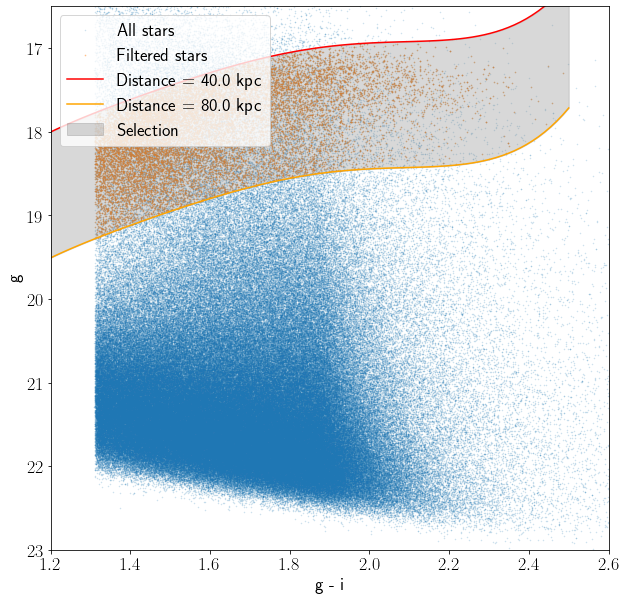

In [7]:
# select RGB in isochrone
isochrone_lmc_rgb = isochrone_lcm_halo.loc[(isochrone_lcm_halo['label'] == 3)]
# fit polynomial to the isochrone in the CMD
coeffs = np.polyfit(isochrone_lmc_rgb['gmag']-isochrone_lmc_rgb['imag'], isochrone_lmc_rgb['gmag'], 5)

# define function to get RGB at a given distance
def rgb_at_distance(distance, coeffs = coeffs):
    return lambda x: np.polyval(coeffs, x) + 5*np.log10(distance/10)

# define function that returns only points that lie between two polynomials
def filter_points_between_polys_astropy(data, x_col, y_col, poly1, poly2):
    """
    Filters and returns points from an Astropy Table that lie between two polynomials.

    Args:
        data: Astropy Table containing the data to be filtered.
        x_col: Name of the column containing X values.
        y_col: Name of the column containing Y values.
        poly1: Function that defines the first polynomial (takes X and returns Y).
        poly2: Function that defines the second polynomial (takes X and returns Y).

    Returns:
        Filtered data as an Astropy Table containing only the points between the two polynomials.
    """
    # Extract the X and Y columns from the table
    x_data = data[x_col]
    y_data = data[y_col]

    # Arrays to store the filtered data
    filtered_rows = []

    # Iterate through each point and apply the filtering
    for i, (x, y) in enumerate(zip(x_data, y_data)):
        poly1_val = poly1(x)
        poly2_val = poly2(x)

        # Determine the lower and upper bounds
        lower_bound = min(poly1_val, poly2_val)
        upper_bound = max(poly1_val, poly2_val)

        # Check if the point is between the two polynomial bounds
        if lower_bound <= y <= upper_bound:
            filtered_rows.append(i)

    # Return the filtered rows as a new Astropy table
    return data[filtered_rows]

# select stars between two isochrones at a given distance range
distance_range = [40000, 80000]
filtered_stars = filter_points_between_polys_astropy(giants[giants['glat'] < 0], x_col = 'g_i', y_col = 'gmag',
                                            poly1=rgb_at_distance(distance=distance_range[0]),
                                             poly2=rgb_at_distance(distance=distance_range[1])) 


# plot the filtered stars and the isochrone and the two polynomials and all stars
#plt.plot(isochrone_lmc_rgb['gmag']-isochrone_lmc_rgb['imag'], isochrone_lmc_rgb['gmag'], 'o', label='Isochrone')
plt.figure(figsize=(10, 10))
x = np.linspace(1, 2.5, 100)
plt.scatter(giants['g_i'], giants['gmag'], s=0.3, label='All stars', alpha=0.2)
plt.scatter(filtered_stars['g_i'], filtered_stars['gmag'], s=0.5, label='Filtered stars', alpha=0.4)
plt.plot(x, rgb_at_distance(distance=distance_range[0])(x), label=f'Distance = {distance_range[0]/1e3} kpc', color='red')
plt.plot(x, rgb_at_distance(distance=distance_range[1])(x), label=f'Distance = {distance_range[1]/1e3} kpc', color='orange')
#plt.plot(x, rgb_at_distance(distance=62000)(x), label=f'Distance = {62} kpc', color='green')
# Shade the area between the two curves
plt.fill_between(x, rgb_at_distance(distance=distance_range[0])(x),rgb_at_distance(distance=distance_range[1])(x), color='gray', alpha=0.3, label='Selection')

plt.xlabel('g - i', fontsize=18)
plt.ylabel('g', fontsize=18)
plt.gca().invert_yaxis()
plt.ylim(23, 16.5)
plt.xlim(1.2, 2.6)
plt.legend(loc = 'upper left')
plt.savefig(os.path.join(plot_path, 'filtered_stars_good_3.png'))
plt.show()

In [8]:
# select stars at low latitude
filtered_stars = filtered_stars[filtered_stars['glat'] < 0]

# Rough $B_{stream}$ selection

Here we will select stars that lie in the correct distance regime and in Magellanic coordinates within a reasonable non-restrictive range yet. I will allow $-50 < B_{MS} < 20$  and $ -125 < L_{MS} < -25$. This way we are outside of the LMC/SMC region in L, and within a reasonable but still open range in B.

In [9]:
filtered_stars_ms_cord = filtered_stars[(filtered_stars['B_stream'] < 20)& (filtered_stars['B_stream'] > -50)& (filtered_stars['L_stream'] > -125) & (filtered_stars['L_stream'] < -25)]

# Copy fig 18

https://arxiv.org/pdf/2408.17250

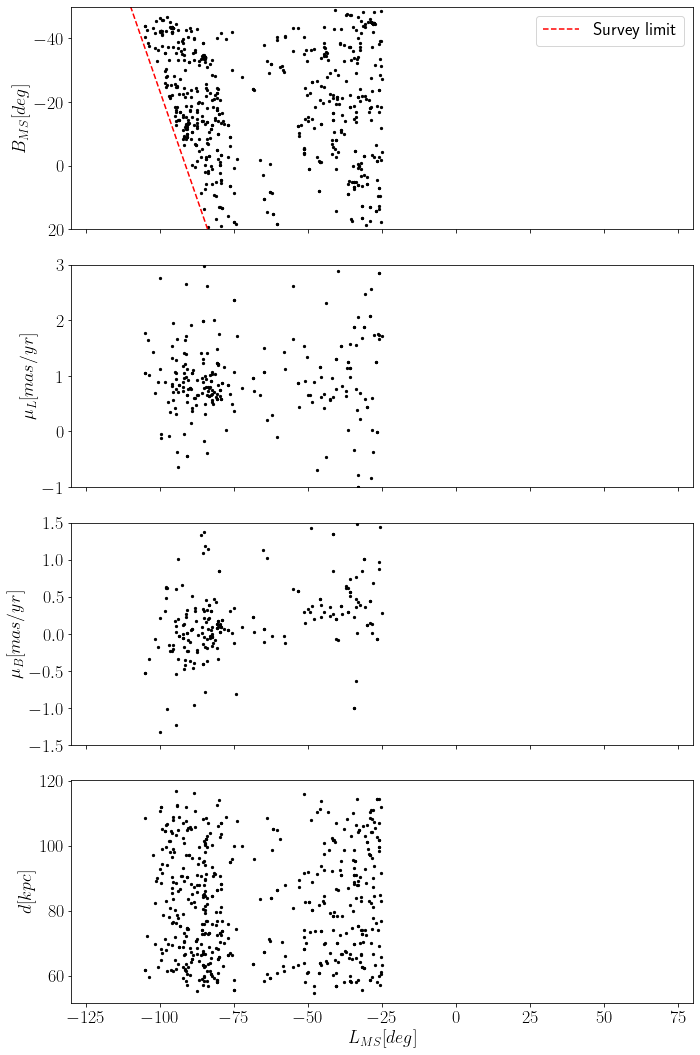

In [10]:
fig, ax = plt.subplots(4, 1, figsize=(20/2, 30/2), sharex=True)
dot_size = 5

ax[0].scatter(filtered_stars_ms_cord['L_stream'], filtered_stars_ms_cord['B_stream'], s=dot_size, c='k')
ax[0].plot([-84, -110], [20, -50], 'r--', label = 'Survey limit')
ax[0].set_ylabel('$B_{MS} [deg]$')
ax[0].set_ylim(20, -50)
ax[0].set_xlim(-130, 80)
ax[0].legend()

ax[1].scatter(filtered_stars_ms_cord['L_stream'], filtered_stars_ms_cord['pm_l'], s=dot_size, c='k')
ax[1].set_ylabel('$\mu_{L} [mas/yr]$')
ax[1].set_ylim(-1, 3)

ax[2].scatter(filtered_stars_ms_cord['L_stream'], filtered_stars_ms_cord['pm_b'], s=dot_size, c='k')
ax[2].set_ylabel('$\mu_{B} [mas/yr]$')
ax[2].set_ylim(-1.5, 1.5)

ax[3].scatter(filtered_stars_ms_cord['L_stream'], filtered_stars_ms_cord['dist_3']/1000, s=dot_size, c='k')
ax[3].set_ylabel('$d [kpc]$')


ax[3].set_xlabel('$L_{MS} [deg]$')


plt.tight_layout()

# Apply cuts in this space


In [11]:
# limit based on mu_l
filtered_stars_f2 = filtered_stars_ms_cord[filtered_stars_ms_cord['pm_l'] > 0]
filtered_stars_f2 = filtered_stars_f2[filtered_stars_f2['pm_l'] < 3]

# limit based on mu_b
filtered_stars_f2 = filtered_stars_f2[filtered_stars_f2['pm_b'] > -0.5]
filtered_stars_f2 = filtered_stars_f2[filtered_stars_f2['pm_b'] < 0.5]

# limit based on distance, for this we will use 2 lines to limit the distance
# Lower line: through (-25, 50) and (-125, 80)
lower_distance = lambda x: 50 - 0.3 * (x + 25)

# Upper line: through (-25, 80) and (-125, 200)
upper_distance = lambda x: 80 - 1.2 * (x + 25)

# Apply the distance filter.
filtered_stars_f2['distance'] =  filtered_stars_f2['dist_3']/1000
# Here we assume that:


filtered_stars_f2 = filtered_stars_f2[
    (filtered_stars_f2['distance'] > lower_distance(filtered_stars_f2['L_stream'])) &
    (filtered_stars_f2['distance'] < upper_distance(filtered_stars_f2['L_stream']))
]

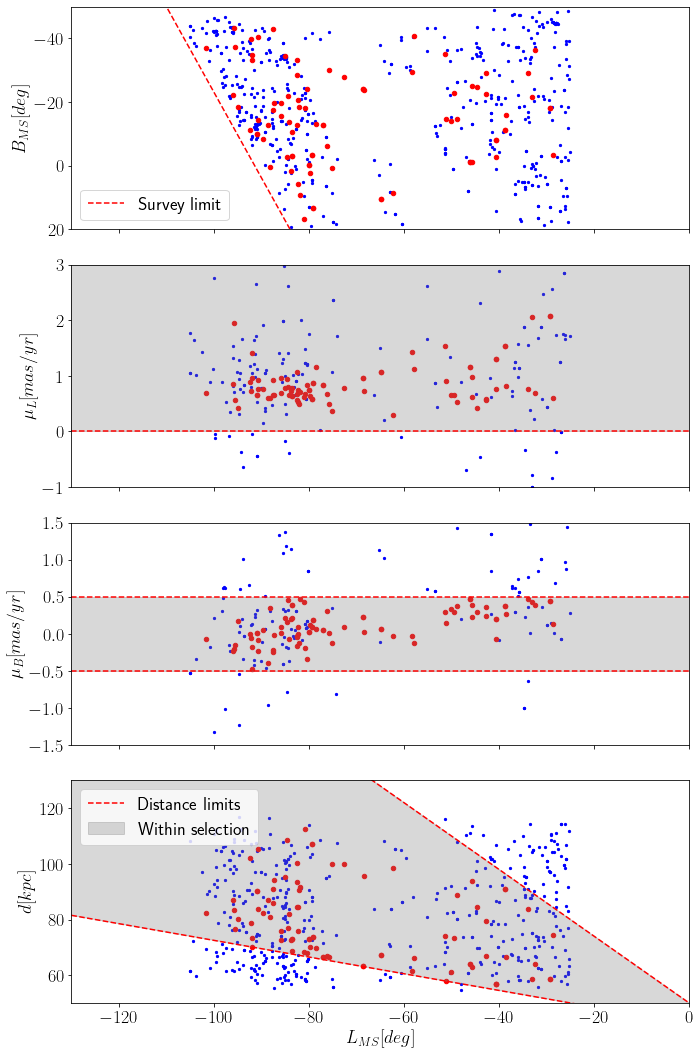

In [34]:
fig, ax = plt.subplots(4, 1, figsize=(20/2, 30/2), sharex=True)
dot_size = 5
dot_size_sel = 20
x = np.linspace(-130, 80, 100)

ax[0].scatter(filtered_stars_ms_cord['L_stream'], filtered_stars_ms_cord['B_stream'], s=dot_size, c='b')
ax[0].scatter(filtered_stars_f2['L_stream'], filtered_stars_f2['B_stream'], s=dot_size_sel, c='r')
ax[0].plot([-84, -110], [20, -50], 'r--', label = 'Survey limit')
ax[0].set_ylabel('$B_{MS} [deg]$')
ax[0].set_ylim(20, -50)
ax[0].set_xlim(-130, 80)
ax[0].legend()

ax[1].scatter(filtered_stars_ms_cord['L_stream'], filtered_stars_ms_cord['pm_l'], s=dot_size, c='b')
ax[1].scatter(filtered_stars_f2['L_stream'], filtered_stars_f2['pm_l'], s=dot_size_sel, c='r', label = 'Selection')
ax[1].hlines(0, -130, 80, 'r', '--', label = 'limit')
# plot grey shaded region between both lines
ax[1].fill_between(x, 0, 3, color='gray', alpha=0.3)
ax[1].set_ylabel('$\mu_{L} [mas/yr]$')
ax[1].set_ylim(-1, 3)

ax[2].scatter(filtered_stars_ms_cord['L_stream'], filtered_stars_ms_cord['pm_b'], s=dot_size, c='b')
ax[2].scatter(filtered_stars_f2['L_stream'], filtered_stars_f2['pm_b'], s=dot_size_sel, c='r')
ax[2].hlines(0.5, -130, 80, 'r', '--', label = 'limit')
ax[2].hlines(-0.5, -130, 80, 'r', '--', label = 'limit')
# plot grey shaded region between both lines
ax[2].fill_between(x, -0.5, 0.5, color='gray', alpha=0.3)
ax[2].set_ylabel('$\mu_{B} [mas/yr]$')
ax[2].set_ylim(-1.5, 1.5)

ax[3].scatter(filtered_stars_ms_cord['L_stream'], filtered_stars_ms_cord['dist_3']/1000, s=dot_size, c='b')
ax[3].scatter(filtered_stars_f2['L_stream'], filtered_stars_f2['dist_3']/1000, s=dot_size_sel, c='r')
# plot the distance limits
x = np.linspace(-130, 80, 100)
ax[3].plot(x, lower_distance(x), 'r--', label = 'Distance limits')
ax[3].plot(x, upper_distance(x), 'r--')
# plot a grey shaded region between both lines
ax[3].fill_between(x, lower_distance(x), upper_distance(x), color='gray', alpha=0.3, label = 'Within selection')

ax[3].set_xlim(-130, 0)
ax[3].set_ylim(50, 130)
ax[3].set_ylabel('$d [kpc]$')
ax[3].set_xlabel('$L_{MS} [deg]$')
ax[3].legend()


plt.tight_layout()
plt.savefig(os.path.join(plot_path, 'filtered_stars_fase2.png'), transparent=False)

In [22]:
len(filtered_stars_f2)

85

In [28]:
filtered_stars_f2.write('/Users/mncavieres/Documents/2024-1/Delve/Proposal/Fase2_Catalog/fase2_catalog.fits', format='fits', overwrite=True)

In [38]:
filtered_stars_f2.sort('mag_psf_g')

In [ ]:
# select top 60 
filtered_stars_f2

a_image_g,a_image_i,a_image_r,a_image_z,b_image_g,b_image_i,b_image_r,b_image_z,ccdnum_g,ccdnum_i,ccdnum_r,ccdnum_z,class_star_g,class_star_i,class_star_r,class_star_z,dec,ebv,expnum_g,expnum_i,expnum_r,expnum_z,exptime_g,exptime_i,exptime_r,exptime_z,extended_class_g,extended_class_i,extended_class_r,extended_class_z,extinction_g,extinction_i,extinction_r,extinction_z,flags_g,flags_i,flags_r,flags_z,hpx2048,htm9,mag_auto_g,mag_auto_i,mag_auto_r,mag_auto_z,mag_psf_g,mag_psf_i,mag_psf_r,mag_psf_z,magerr_auto_g,magerr_auto_i,magerr_auto_r,magerr_auto_z,magerr_psf_g,magerr_psf_i,magerr_psf_r,magerr_psf_z,nepochs_g,nepochs_i,nepochs_r,nepochs_z,nest4096,quick_object_id,ra,random_id,ring256,spread_model_g,spread_model_i,spread_model_r,spread_model_z,spreaderr_model_g,spreaderr_model_i,spreaderr_model_r,spreaderr_model_z,t_eff_g,t_eff_i,t_eff_r,t_eff_z,theta_image_g,theta_image_i,theta_image_r,theta_image_z,wavg_flags_g,wavg_flags_i,wavg_flags_r,wavg_flags_z,wavg_mag_auto_g,wavg_mag_auto_i,wavg_mag_auto_r,wavg_mag_auto_z,wavg_mag_psf_g,wavg_mag_psf_i,wavg_mag_psf_r,wavg_mag_psf_z,wavg_magerr_auto_g,wavg_magerr_auto_i,wavg_magerr_auto_r,wavg_magerr_auto_z,wavg_magerr_psf_g,wavg_magerr_psf_i,wavg_magerr_psf_r,wavg_magerr_psf_z,wavg_magrms_auto_g,wavg_magrms_auto_i,wavg_magrms_auto_r,wavg_magrms_auto_z,wavg_magrms_psf_g,wavg_magrms_psf_i,wavg_magrms_psf_r,wavg_magrms_psf_z,wavg_spread_model_g,wavg_spread_model_i,wavg_spread_model_r,wavg_spread_model_z,wavg_spreaderr_model_g,wavg_spreaderr_model_i,wavg_spreaderr_model_r,wavg_spreaderr_model_z,wavg_spreadrms_model_g,wavg_spreadrms_model_i,wavg_spreadrms_model_r,wavg_spreadrms_model_z,mjd_obs,elon,elat,glon,glat,on_sky_distance_arcsec,SOURCEID,CUEVENTID,FRAMESETID,RA2000,DEC2000,L,B,LAMBDA,ETA,PRIORSEC,YMJPNT,YMJPNTERR,JMHPNT,JMHPNTERR,HMKSPNT,HMKSPNTERR,JMKSPNT,JMKSPNTERR,YMJEXT,YMJEXTERR,JMHEXT,JMHEXTERR,HMKSEXT,HMKSEXTERR,JMKSEXT,JMKSEXTERR,MERGEDCLASSSTAT,MERGEDCLASS,PSTAR,PGALAXY,PNOISE,PSATURATED,EBV,AY,AJ,AH,AKS,YMJD,YPETROMAG,YPETROMAGERR,YPSFMAG,YPSFMAGERR,YSERMAG2D,YSERMAG2DERR,YAPERMAG3,YAPERMAG3ERR,YAPERMAG4,YAPERMAG4ERR,YAPERMAG6,YAPERMAG6ERR,YAPERMAGNOAPERCORR3,YAPERMAGNOAPERCORR4,YAPERMAGNOAPERCORR6,YHLCORSMJRADAS,YGAUSIG,YELL,YPA,YERRBITS,YAVERAGECONF,YCLASS,YCLASSSTAT,YPPERRBITS,YSEQNUM,YXI,YETA,JMJD,JPETROMAG,JPETROMAGERR,JPSFMAG,JPSFMAGERR,JSERMAG2D,JSERMAG2DERR,JAPERMAG3,JAPERMAG3ERR,JAPERMAG4,JAPERMAG4ERR,JAPERMAG6,JAPERMAG6ERR,JAPERMAGNOAPERCORR3,JAPERMAGNOAPERCORR4,JAPERMAGNOAPERCORR6,JHLCORSMJRADAS,JGAUSIG,JELL,JPA,JERRBITS,JAVERAGECONF,JCLASS,JCLASSSTAT,JPPERRBITS,JSEQNUM,JXI,JETA,HMJD,HPETROMAG,HPETROMAGERR,HPSFMAG,HPSFMAGERR,HSERMAG2D,HSERMAG2DERR,HAPERMAG3,HAPERMAG3ERR,HAPERMAG4,HAPERMAG4ERR,HAPERMAG6,HAPERMAG6ERR,HAPERMAGNOAPERCORR3,HAPERMAGNOAPERCORR4,HAPERMAGNOAPERCORR6,HHLCORSMJRADAS,HGAUSIG,HELL,HPA,HERRBITS,HAVERAGECONF,HCLASS,HCLASSSTAT,HPPERRBITS,HSEQNUM,HXI,HETA,KSMJD,KSPETROMAG,KSPETROMAGERR,KSPSFMAG,KSPSFMAGERR,KSSERMAG2D,KSSERMAG2DERR,KSAPERMAG3,KSAPERMAG3ERR,KSAPERMAG4,KSAPERMAG4ERR,KSAPERMAG6,KSAPERMAG6ERR,KSAPERMAGNOAPERCORR3,KSAPERMAGNOAPERCORR4,KSAPERMAGNOAPERCORR6,KSHLCORSMJRADAS,KSGAUSIG,KSELL,KSPA,KSERRBITS,KSAVERAGECONF,KSCLASS,KSCLASSSTAT,KSPPERRBITS,KSSEQNUM,KSXI,KSETA,PRIMARY_SOURCE,g_i,i_Ks,gmag,dist_1,g_ABS_1,dist_2,g_ABS_2,dist_3,g_ABS_3,dist_4,g_ABS_4,L_stream,B_stream,ra_epoch2000,dec_epoch2000,errHalfMaj,errHalfMin,errPosAng,source_id,ra_x,ra_error,dec_x,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,astrometric_n_good_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,pseudocolour,pseudocolour_error,visibility_periods_used,ruwe,duplicated_source,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_mag,phot_rp_mean_flux,phot_rp_mean_mag,phot_bp_rp_excess_factor,bp_rp,dr2_radial_velocity,dr2_radial_velocity_error,dr2_rv_nb_transits,dr2_rv_template_teff,dr2_rv